In [1]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path("/project/def-nahee/kbas/Graphnet-Applications/Metadata/DatasetStatistics/TruthLevelStatistics")
FLAVOR_FILES = {
    "Muon": DATA_DIR / "Muon.csv",
    "Electron": DATA_DIR / "Electron.csv",
    "Tau": DATA_DIR / "Tau.csv",
    "NC": DATA_DIR / "NC.csv",
}

EVENT_COLUMNS = ["RunID", "SubrunID", "EventID", "SubEventID"]
TRUTH_COLUMNS = ["pid", "is_CC", "totalEnergy", "zenith", "azimuth", "final_weight"]
TRIGGER_COLUMNS = [
    "triggered_nonoise_102_string",
    "triggered_nonoise_160_string",
    "triggered_nonoise_340_string",
]
USE_COLUMNS = EVENT_COLUMNS + TRUTH_COLUMNS + TRIGGER_COLUMNS
TRIGGER_RENAME = {
    "triggered_nonoise_102_string": "trigger_102",
    "triggered_nonoise_160_string": "trigger_160",
    "triggered_nonoise_340_string": "trigger_340",
}

flavor_frames = []
for flavor, csv_path in FLAVOR_FILES.items():
    triggered_chunks = []
    for chunk in pd.read_csv(csv_path, usecols=USE_COLUMNS, chunksize=250_000):
        trigger_mask = chunk[TRIGGER_COLUMNS].eq(1).any(axis=1)
        triggered_chunks.append(chunk.loc[trigger_mask].copy())

    flavor_df = pd.concat(triggered_chunks, ignore_index=True)
    flavor_df.insert(0, "flavor", flavor)
    flavor_frames.append(flavor_df)
    print(f"{flavor:8s}: {len(flavor_df):,} events triggered in at least one geometry")

master_df = pd.concat(flavor_frames, ignore_index=True).rename(columns=TRIGGER_RENAME)
for column in TRIGGER_RENAME.values():
    master_df[column] = master_df[column].eq(1)

master_df = master_df[[
    "flavor", *EVENT_COLUMNS, *TRUTH_COLUMNS, "trigger_102", "trigger_160", "trigger_340"
]]

print(f"\nMaster dataframe: {len(master_df):,} events x {master_df.shape[1]} columns")
display(master_df.head())


Muon    : 424,104 events triggered in at least one geometry
Electron: 170,003 events triggered in at least one geometry
Tau     : 249,816 events triggered in at least one geometry
NC      : 188,859 events triggered in at least one geometry

Master dataframe: 1,032,782 events x 14 columns


,flavor,RunID,SubrunID,EventID,SubEventID,pid,is_CC,totalEnergy,zenith,azimuth,final_weight,trigger_102,trigger_160,trigger_340
0,Muon,0,4294967295,1,0,14,1,119.300665,2.129418,1.378987,1.693436e+01,True,True,True
1,Muon,0,4294967295,11,0,14,1,103.471686,2.613390,1.610513,1.402100e+01,False,False,True
2,Muon,0,4294967295,14,0,14,1,633.429111,0.681382,2.099105,1.561357e+03,False,False,True
3,Muon,0,4294967295,15,0,14,1,144.724868,2.022539,5.724277,2.855577e+01,True,True,True
4,Muon,0,4294967295,18,0,14,1,111663.155939,0.167123,3.115837,2.054246e+08,True,True,True


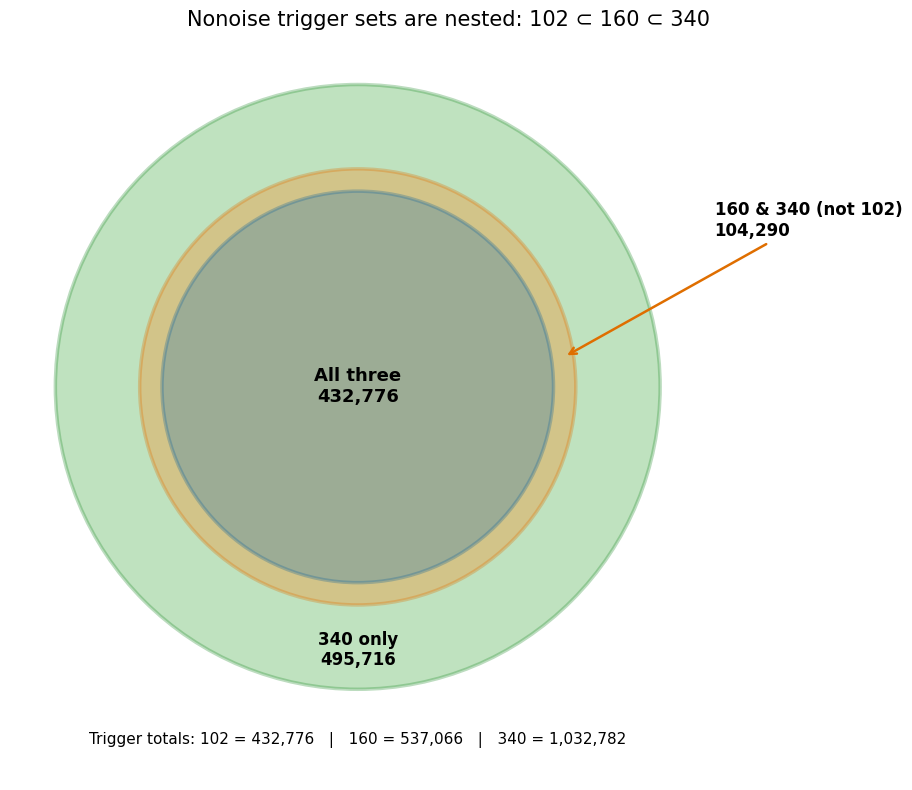

In [3]:
import math

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

t102 = master_df["trigger_102"]
t160 = master_df["trigger_160"]
t340 = master_df["trigger_340"]

all_three = int((t102 & t160 & t340).sum())
middle_only = int((~t102 & t160 & t340).sum())
outer_only = int((~t102 & ~t160 & t340).sum())
non_nested = int((t102 & ~t160).sum() + (t160 & ~t340).sum())
if non_nested:
    raise ValueError(f"Trigger sets are not nested; found {non_nested:,} violating events.")

total_102 = int(t102.sum())
total_160 = int(t160.sum())
total_340 = int(t340.sum())

# Circle areas are proportional to the total number of triggered events.
r340 = 1.00
r160 = math.sqrt(total_160 / total_340)
r102 = math.sqrt(total_102 / total_340)

fig, ax = plt.subplots(figsize=(10, 8))
for radius, facecolor, edgecolor in [
    (r340, "#2ca02c", "#218c2b"),
    (r160, "#ff7f0e", "#df6e00"),
    (r102, "#1f77b4", "#17649a"),
]:
    ax.add_patch(Circle((0, 0), radius, facecolor=facecolor, edgecolor=edgecolor, alpha=0.30, linewidth=2.5))

ax.text(0, 0, f"All three\n{all_three:,}", ha="center", va="center", fontsize=13, fontweight="bold")
ax.annotate(
    f"160 & 340 (not 102)\n{middle_only:,}",
    xy=((r102 + r160) / 2, 0.10),
    xytext=(1.18, 0.55),
    ha="left",
    va="center",
    fontsize=12,
    fontweight="bold",
    arrowprops={"arrowstyle": "->", "color": "#df6e00", "lw": 1.8},
)
ax.text(0, -0.87, f"340 only\n{outer_only:,}", ha="center", va="center", fontsize=12, fontweight="bold")

ax.set_title("Nonoise trigger sets are nested: 102 ⊂ 160 ⊂ 340", fontsize=15, pad=16)
ax.text(
    0,
    -1.18,
    f"Trigger totals: 102 = {total_102:,}   |   160 = {total_160:,}   |   340 = {total_340:,}",
    ha="center",
    fontsize=11,
)
ax.set_xlim(-1.15, 1.75)
ax.set_ylim(-1.30, 1.12)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.show()
